In [1]:
# Customer Churn Prediction System

In [2]:
#1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
#2. Load Dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#3. Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [5]:
#4. Dataset Information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
#5. Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
#6. Missing Values Analysis
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
#7. Data Cleaning
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.shape

(7032, 21)

In [9]:
#8. Unique Value Analysis

for col in df.columns:
    print(col, ":", df[col].nunique())

customerID : 7032
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 72
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1584
TotalCharges : 6530
Churn : 2


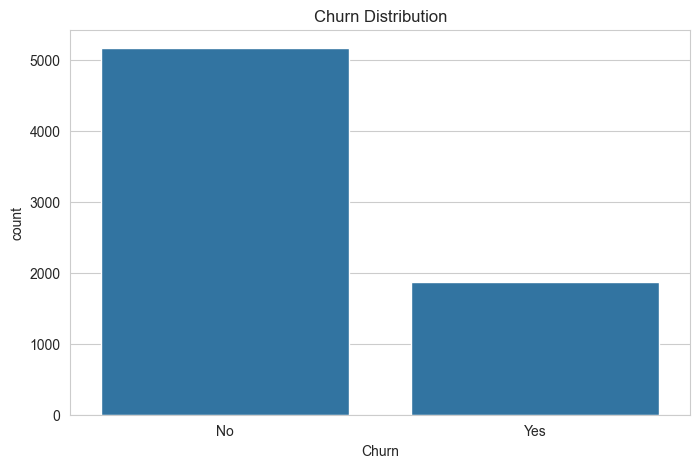

In [10]:
#9.  Target Variable Distribution

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Churn Distribution")

plt.show() 

In [11]:
#10. Churn Percentage

churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


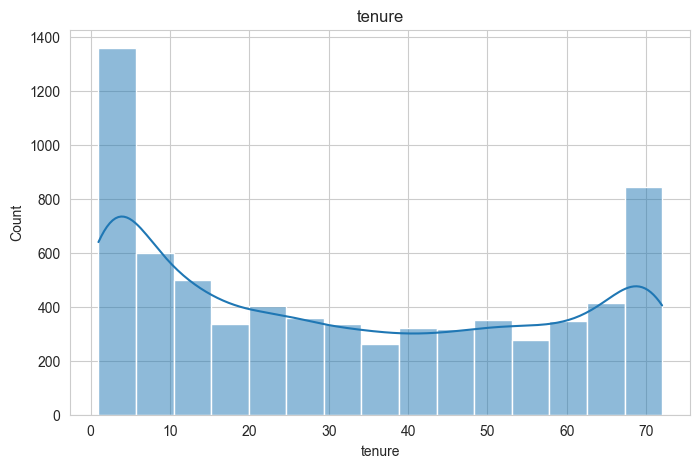

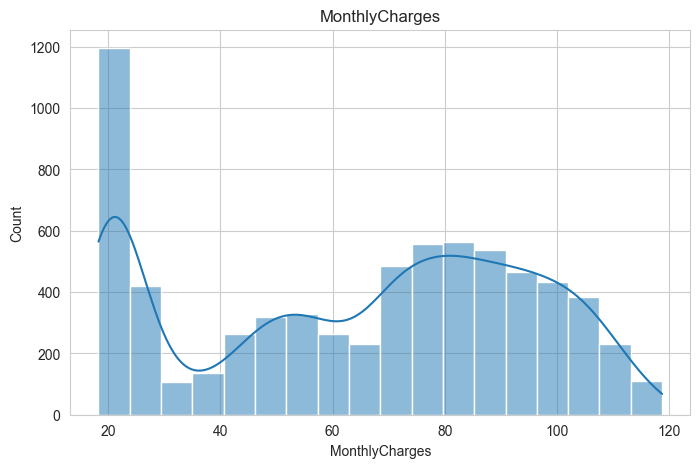

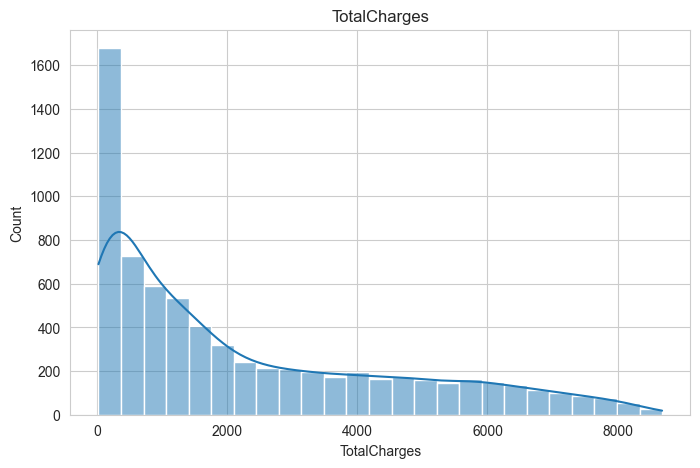

In [12]:
#11. Numerical Features Distribution

numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numeric_cols:

    plt.figure()

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

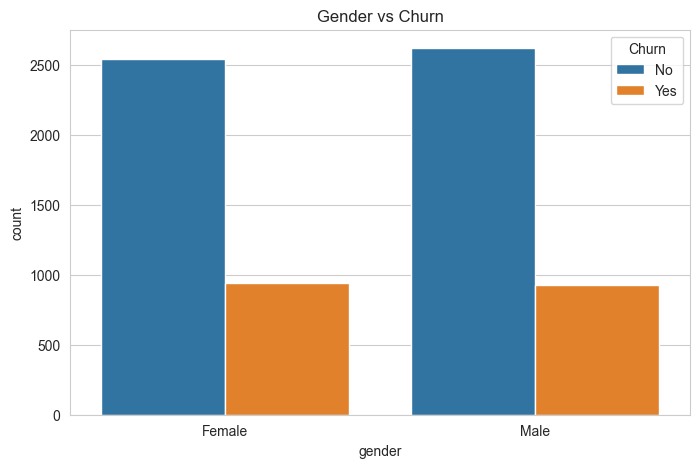

In [13]:
#12. Gender vs Churn

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

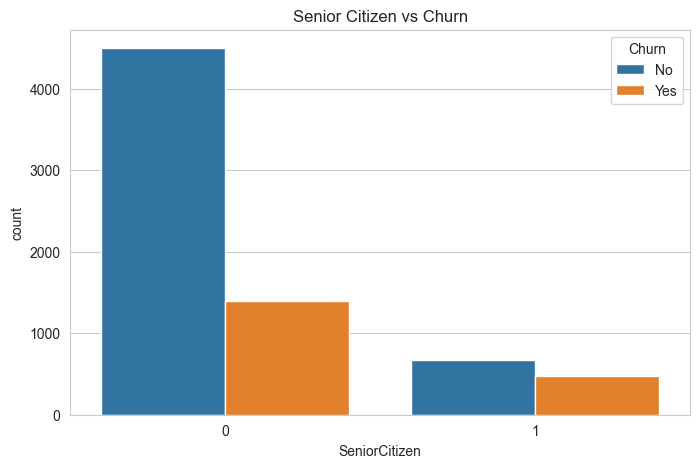

In [14]:
#13. Senior Citizen vs Churn
sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.show()

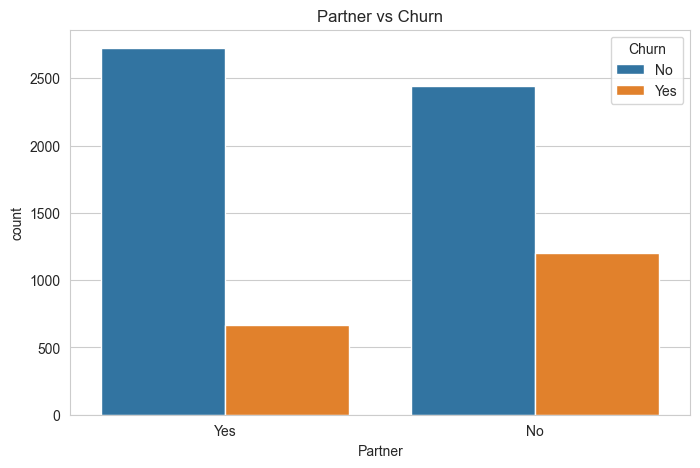

In [15]:
#14. Partner vs Churn
sns.countplot(
    x="Partner",
    hue="Churn",
    data=df
)

plt.title("Partner vs Churn")

plt.show()

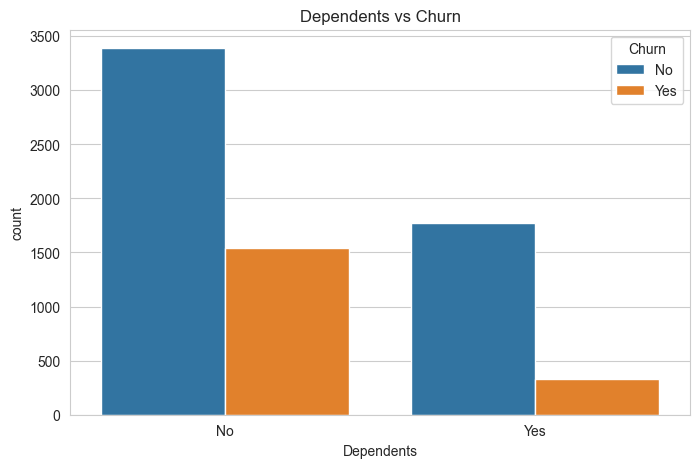

In [16]:
#15. Dependents vs Churn
sns.countplot(
    x="Dependents",
    hue="Churn",
    data=df
)

plt.title("Dependents vs Churn")

plt.show()

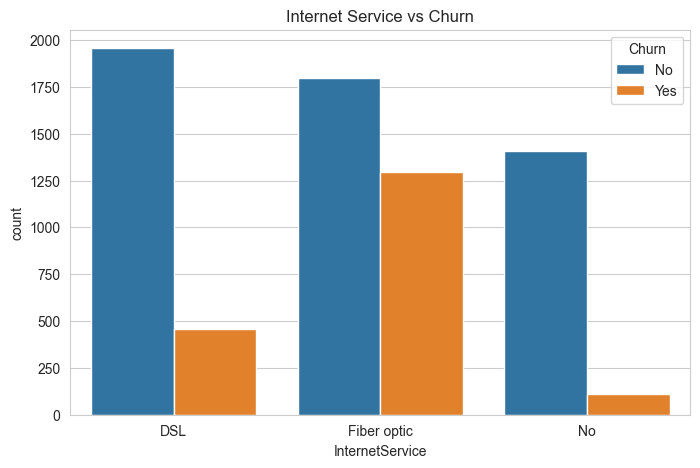

In [17]:
#16. Internet Service vs Churn

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

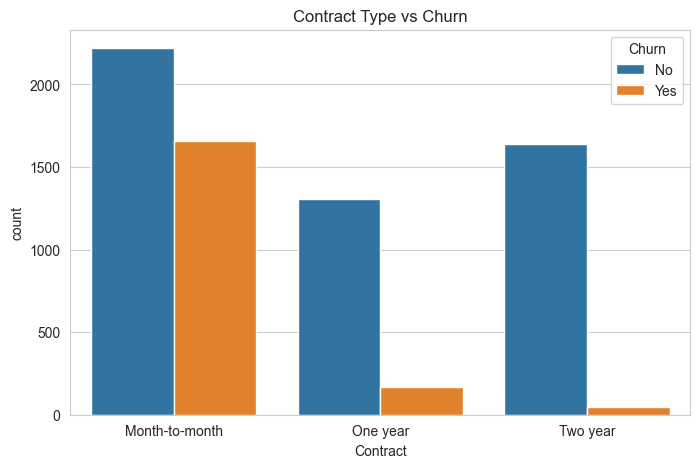

In [18]:
#17. Contract Type vs Churn
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

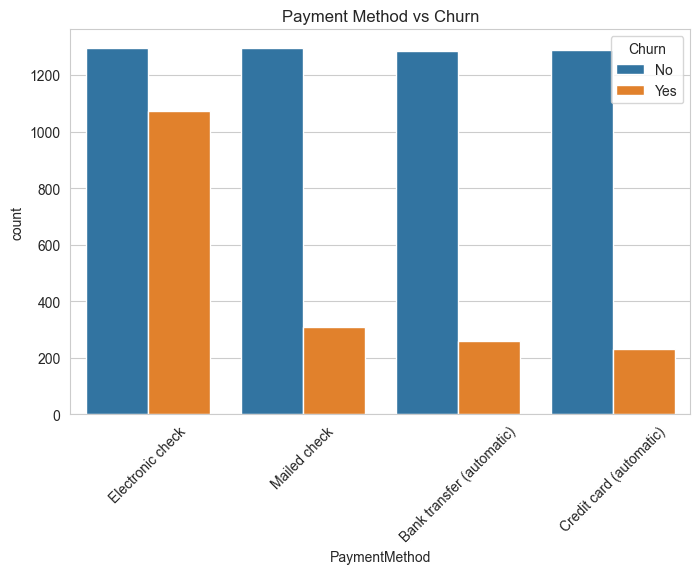

In [19]:
#18. Payment Method vs Churn
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

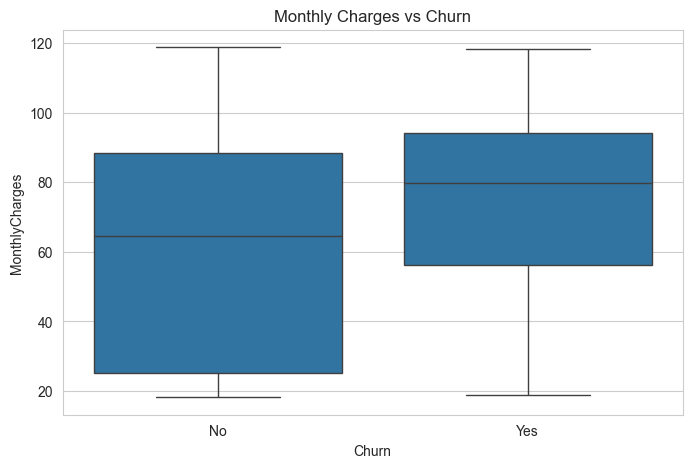

In [20]:
#19. Monthly Charges vs Churn
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

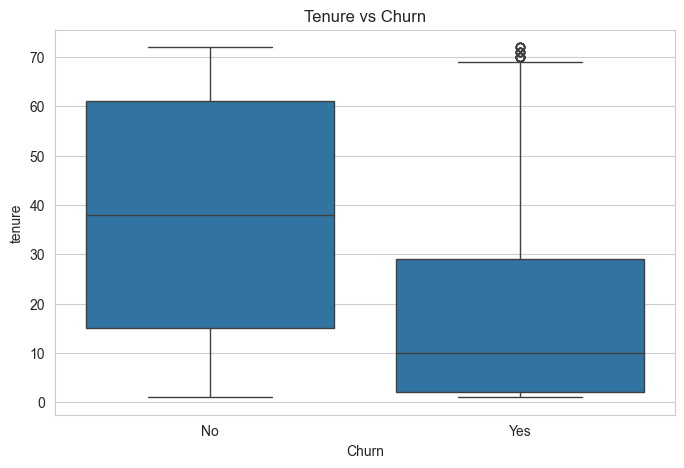

In [21]:
#20. Tenure vs Churn
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

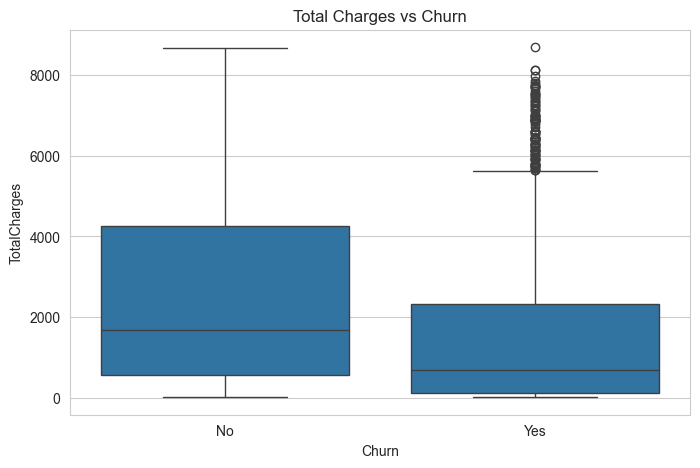

In [22]:
#21. Total Charges vs Churn
sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges vs Churn")

plt.show()

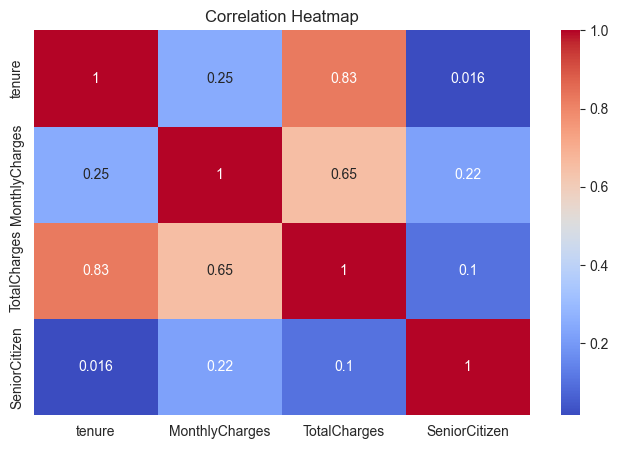

In [23]:
#22. Correlation Heatmap
corr_df = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "SeniorCitizen"
    ]
]

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

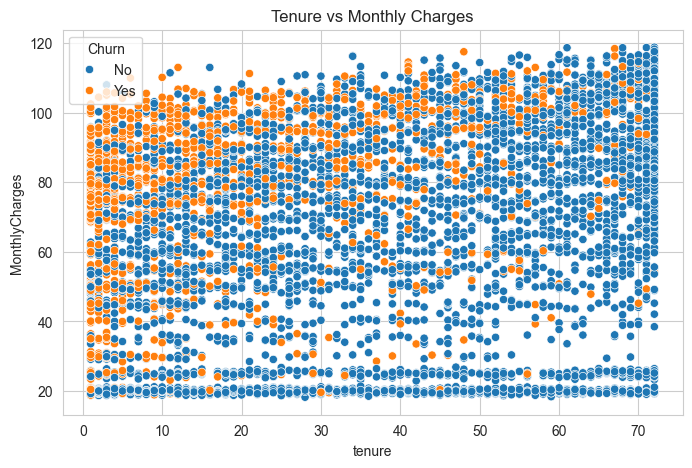

In [24]:
#23. Tenure vs Monthly Charges
sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    data=df
)

plt.title("Tenure vs Monthly Charges")

plt.show()

In [25]:
#24. Key Insights
print("""
Key Insights:

1. Month-to-month customers churn more.
2. Customers with low tenure churn more.
3. High monthly charges increase churn risk.
4. Long-term contracts reduce churn.
5. Fiber optic customers show relatively high churn.
6. Senior citizens churn more than non-senior customers.
""")


Key Insights:

1. Month-to-month customers churn more.
2. Customers with low tenure churn more.
3. High monthly charges increase churn risk.
4. Long-term contracts reduce churn.
5. Fiber optic customers show relatively high churn.
6. Senior citizens churn more than non-senior customers.

